**Step 1. Show the first few lines of the csv to see if the csv file is successfully able to be read.**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# absolute path 
df = pd.read_csv("/Users/evelyn/Documents/claudecode/speechlab/week-04/torgo_egemaps_summary.csv")
df.head() 

,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
0,'F01-Session1-wav_headMic-0116.wav',0.0,38.33156,0.109528,38.26910,39.06808,40.05841,1.789307,587.163300,866.361800,...,0.010385,0.057815,2.145046,2.363823,0.208696,0.159437,0.175600,0.167811,-25.17384,1
1,'MC03-Session1-wav_headMic-0586.wav',0.0,14.02498,0.154655,13.52956,13.53839,13.55250,0.022939,5.641339,3.890914,...,-0.003398,0.834803,1.234568,2.564103,0.355000,0.353589,0.023333,0.004714,-19.72760,0
2,'FC03-Session1-wav_headMic-0242.wav',0.0,32.16512,0.303630,13.59434,36.37801,38.03387,24.439530,193.087900,143.710900,...,-0.002278,0.339914,2.583026,3.773585,0.120000,0.098184,0.112727,0.104367,-16.56605,0
3,'MC01-Session2-wav_headMic-0268.wav',0.0,17.04129,0.346149,12.60095,13.40295,24.97907,12.378120,16.843840,13.457780,...,0.019647,0.035664,1.255230,2.991453,0.052857,0.039538,0.222500,0.208312,-39.51396,0
4,'MC02-Session1-wav_headMic-0068.wav',0.0,17.30344,0.233548,13.53755,16.78878,21.44546,7.907907,46.656320,76.326760,...,0.000590,0.405793,2.285714,2.312139,0.320000,0.253048,0.111000,0.040608,-16.57751,0


**Step 2. Check to see that the output is what I expected.**

I used openSMILE toolkit to extract eGeMAPS features, so I should expect to see 8000+ rows representing audio files, each with a set of 88 features.

Here are the checks I am performing: 
- df.shape — prints (rows, columns) to confirm 8,185 rows (we started off with 8,216 audio file inputs, but 31 of them failed to produce output) and 91 columns (88 eGeMAPS + name + frameTime)
- df["label"].value_counts() — counts how many dysarthric (1) vs control (0) files there are, so you can see if the dataset is balanced or imbalanced
- df.isnull().sum().sum() — counts any missing values across the whole dataframe (could happen if SMILExtract failed on some features)

In [4]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (8185, 91)

Class distribution:
label
0    5220
1    2965
Name: count, dtype: int64

Missing values: 0


**Step 3. Visualize feature distributions**

Plot histograms for the feature distributions of key features, split by whether the speaker has the control (0) or dysarthia (1) label. By looking for a clear separation between median and spread of the graph, this helps us determine if that feature is useful in distinguishing between the two groups.

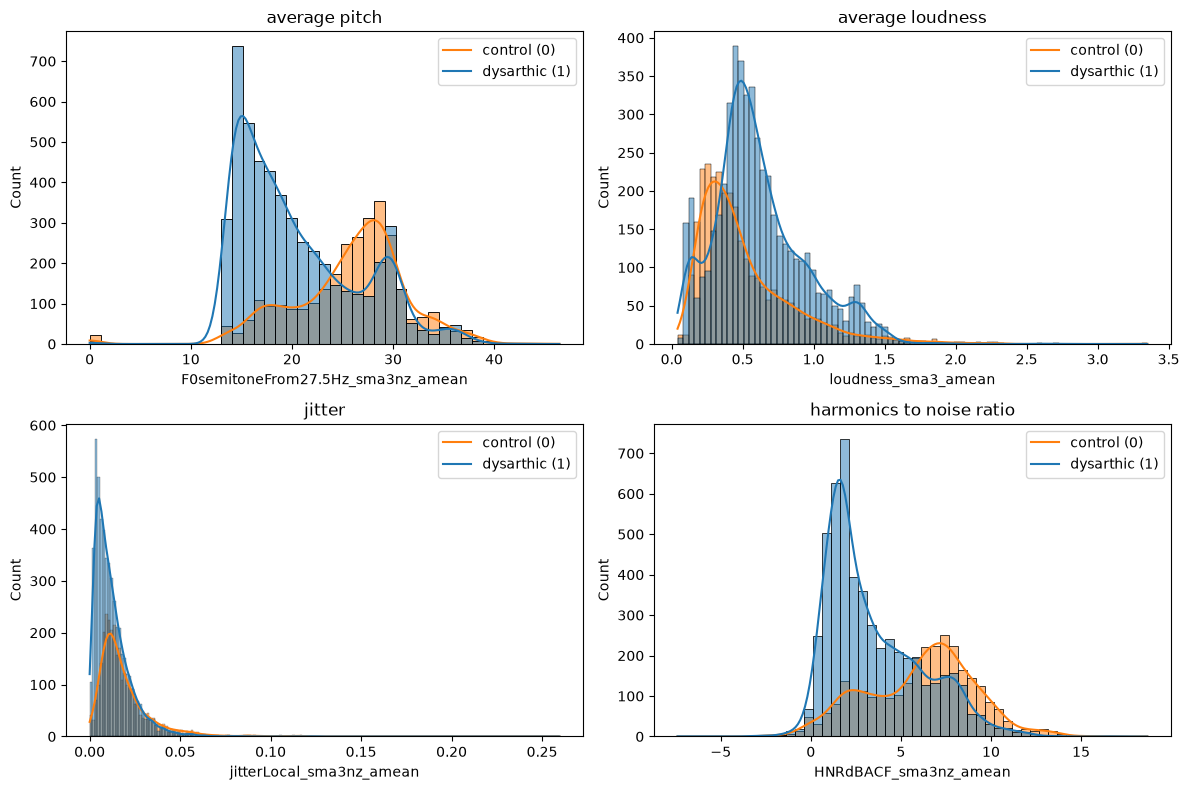

In [9]:
# dict for human understandable features
features_to_plot = {
    "F0semitoneFrom27.5Hz_sma3nz_amean": "average pitch",  
    "loudness_sma3_amean": "average loudness",                 
    "jitterLocal_sma3nz_amean": "jitter",             
    "HNRdBACF_sma3nz_amean" : "harmonics to noise ratio",              
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()



for i, (feature, description) in enumerate(features_to_plot.items()):
    sns.histplot(data=df, x=feature, hue="label", ax=axes[i], kde=True)
    axes[i].set_title(description)
    axes[i].legend(["control (0)", "dysarthic (1)"])

plt.tight_layout()
plt.show()

It's useful to analyze the graphs and see if it matches our human intuition and knowledge about the disease. In general, speakers with dysarthia show these patterns: their voice is "less smooth/steady" and sounds rough or hoarse, less control.

Here is a comparison of what we expect to see and what shows up on the graph. 
- Pitch (F0) — dysarthric speakers often have more monotone or irregular pitch, so the average pitch should be lower -> the median of the blue graph is lower!
- Loudness — dysarthric speech can be quieter or more variable -> the dysarthia speakers actually have a louder volume and similar variance
- Jitter — expect dysarthric speakers to have higher jitter (more irregular vocal fold vibration due to motor control issues) -> not much of a difference
- HNR — expect dysarthric speakers to have lower HNR (noisier, less periodic voice) -> yes, this is pretty clearly reflected! the blue graph is to the left